In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
import pickle

In [2]:
# plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 16
SAVEFIG = False

In [3]:
df = pd.read_csv("simu6a_data/simu6a_Kahana.csv", header=[0, 1])
df

,backward,Unnamed: 1_level_0,forward,Unnamed: 3_level_0
,X,Y,X,Y
0,0.011161,0.995442,0.011161,0.998860
1,2.020089,0.618234,2.020089,0.659259
2,4.017857,0.333333,4.006696,0.291168
3,6.004464,0.268376,6.004464,0.298006
4,8.013393,0.255840,8.013393,0.276353
5,10.000000,0.343590,10.000000,0.304843


In [4]:
df.columns = ["Backward_X", "Backward_Y", "Forward_X", "Forward_Y"]
x_range = np.arange(6)
df["Backward_X"] = x_range
df["Forward_X"] = x_range
df

,Backward_X,Backward_Y,Forward_X,Forward_Y
0,0,0.995442,0,0.998860
1,1,0.618234,1,0.659259
2,2,0.333333,2,0.291168
3,3,0.268376,3,0.298006
4,4,0.255840,4,0.276353
5,5,0.343590,5,0.304843


In [5]:
# save gt as pkl
with open("simu6a_data/simu6a_gt.pkl", "wb") as f:
    pickle.dump(df["Forward_Y"].to_numpy(), f)
    pickle.dump(df["Backward_Y"].to_numpy(), f)

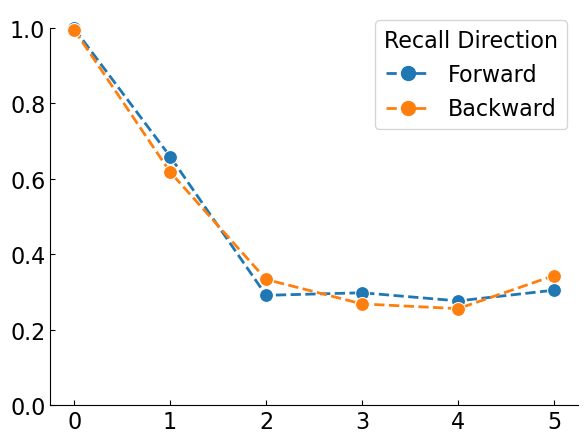

In [6]:
fig, ax = plt.subplots(figsize=(6, 4.5))
fig.subplots_adjust(left=0.1, right=0.98, bottom=0.1, top=0.98)

sns.lineplot(data=df, x="Forward_X", y="Forward_Y", linewidth=2, marker="o", markersize=10, label="Forward", linestyle="--")
sns.lineplot(data=df, x="Backward_X", y="Backward_Y", linewidth=2, marker="o", markersize=10, label="Backward", linestyle="--")
ax.spines["left"].set_bounds(0, 1)
ax.spines[["right", "top"]].set_visible(False)
ax.tick_params(axis="y", direction="in")
ax.tick_params(axis="x", direction="in")
plt.ylim([0, 1.05])
plt.xlabel("Test Lag")
plt.ylabel("Proposition Correct")
ax.set(xlabel=None, ylabel=None)
legend_elements = [Line2D([0], [0], color=sns.color_palette()[0], lw=2, marker="o", markersize=10, linestyle="--", label="Forward"), Line2D([0], [0], color=sns.color_palette()[1], lw=2, marker="o", markersize=10, linestyle="--", label="Backward")]
plt.legend(handles=legend_elements, title="Recall Direction")

if SAVEFIG:
    plt.savefig("simu6a_fig/simu6a_Kahana.pdf")